# Estudo Prático - Algoritimos de Classificação Supervisionados

---
## **Análise dos Dados**
---

Para esse estudo foi usado os dados do dataset mental-health-disorder, que contem informações sobre 25.000 indivíduos, classificados em três níveis de risco de saúde mental: Risco Baixo, Risco Moderado e Risco Alto. Cada indivíduo é caracterizado por variáveis divididas em cinco categorias de atributos:

* informações demográficas (idade, gênero,
estado civil, escolaridade, status de emprego)

* fatores de estilo de vida (horas de sono, atividade física, tempo de tela, suporte social)

* indicadores de estresse (pressão acadêmica, estresse no trabalho e financeiro, satisfação)

* indicadores psicológicos (pontuação de ansiedade e depressão, oscilações de humor, etc.)

* histórico médico e familiar (histórico familiar de doença mental, histórico de terapia, etc.)

* classe (Risco Baixo, Risco Moderado, Risco Alto)

Link para download do arquivo: https://www.kaggle.com/datasets/guriya79/mental-health-disorder

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
dataset =  pd.read_csv("/content/drive/MyDrive/Dados_Exploratorios_dataset-cvs/datasets/mental_health_risk_dataset.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
dataset.head()

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.6,2.8,9.6,7,10,...,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.5,2.7,3.0,10,6,...,7,4,9,3,0,0,0,0,0,0
2,56,Female,Divorced,Bachelor,Student,3.1,14.1,7.2,10,5,...,3,1,4,2,1,1,1,1,1,2
3,59,Other,Married,Bachelor,Employed,7.0,0.5,10.3,2,10,...,8,5,2,5,1,1,0,1,1,2
4,58,Male,Single,High School,Self-Employed,5.1,2.5,1.2,8,1,...,8,3,3,1,0,0,1,0,1,0


In [21]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               25000 non-null  int64  
 1   gender                            25000 non-null  object 
 2   marital_status                    25000 non-null  object 
 3   education_level                   25000 non-null  object 
 4   employment_status                 25000 non-null  object 
 5   sleep_hours                       25000 non-null  float64
 6   physical_activity_hours_per_week  25000 non-null  float64
 7   screen_time_hours_per_day         25000 non-null  float64
 8   social_support_score              25000 non-null  int64  
 9   work_stress_level                 25000 non-null  int64  
 10  academic_pressure_level           25000 non-null  int64  
 11  job_satisfaction_score            25000 non-null  int64  
 12  fina

In [22]:
dataset.describe()

,age,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,working_hours_per_week,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,39.072560,6.509516,7.515400,6.469132,5.50840,5.517080,5.445880,5.471040,5.495080,45.049600,...,5.534000,5.520480,5.512880,5.488240,0.497840,0.504280,0.504160,0.501640,0.499120,0.778520
std,12.404948,2.015586,4.324346,3.167682,2.88694,2.864548,2.864479,2.867816,2.881636,14.683297,...,2.870048,2.873213,2.870596,2.873178,0.500005,0.499992,0.499993,0.500007,0.500009,0.691409
min,18.000000,3.000000,0.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,20.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,4.800000,3.800000,3.700000,3.00000,3.000000,3.000000,3.000000,3.000000,32.000000,...,3.000000,3.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,39.000000,6.500000,7.500000,6.500000,5.00000,6.000000,5.000000,5.000000,5.000000,45.000000,...,6.000000,6.000000,6.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
75%,50.000000,8.200000,11.300000,9.200000,8.00000,8.000000,8.000000,8.000000,8.000000,58.000000,...,8.000000,8.000000,8.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,60.000000,10.000000,15.000000,12.000000,10.00000,10.000000,10.000000,10.000000,10.000000,70.000000,...,10.000000,10.000000,10.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000


---
## Análise Grafica Inicial
---

Analisando a distribuição das variaveis numericas do dataset, para procurar padrões e entender como os dados se relacionam




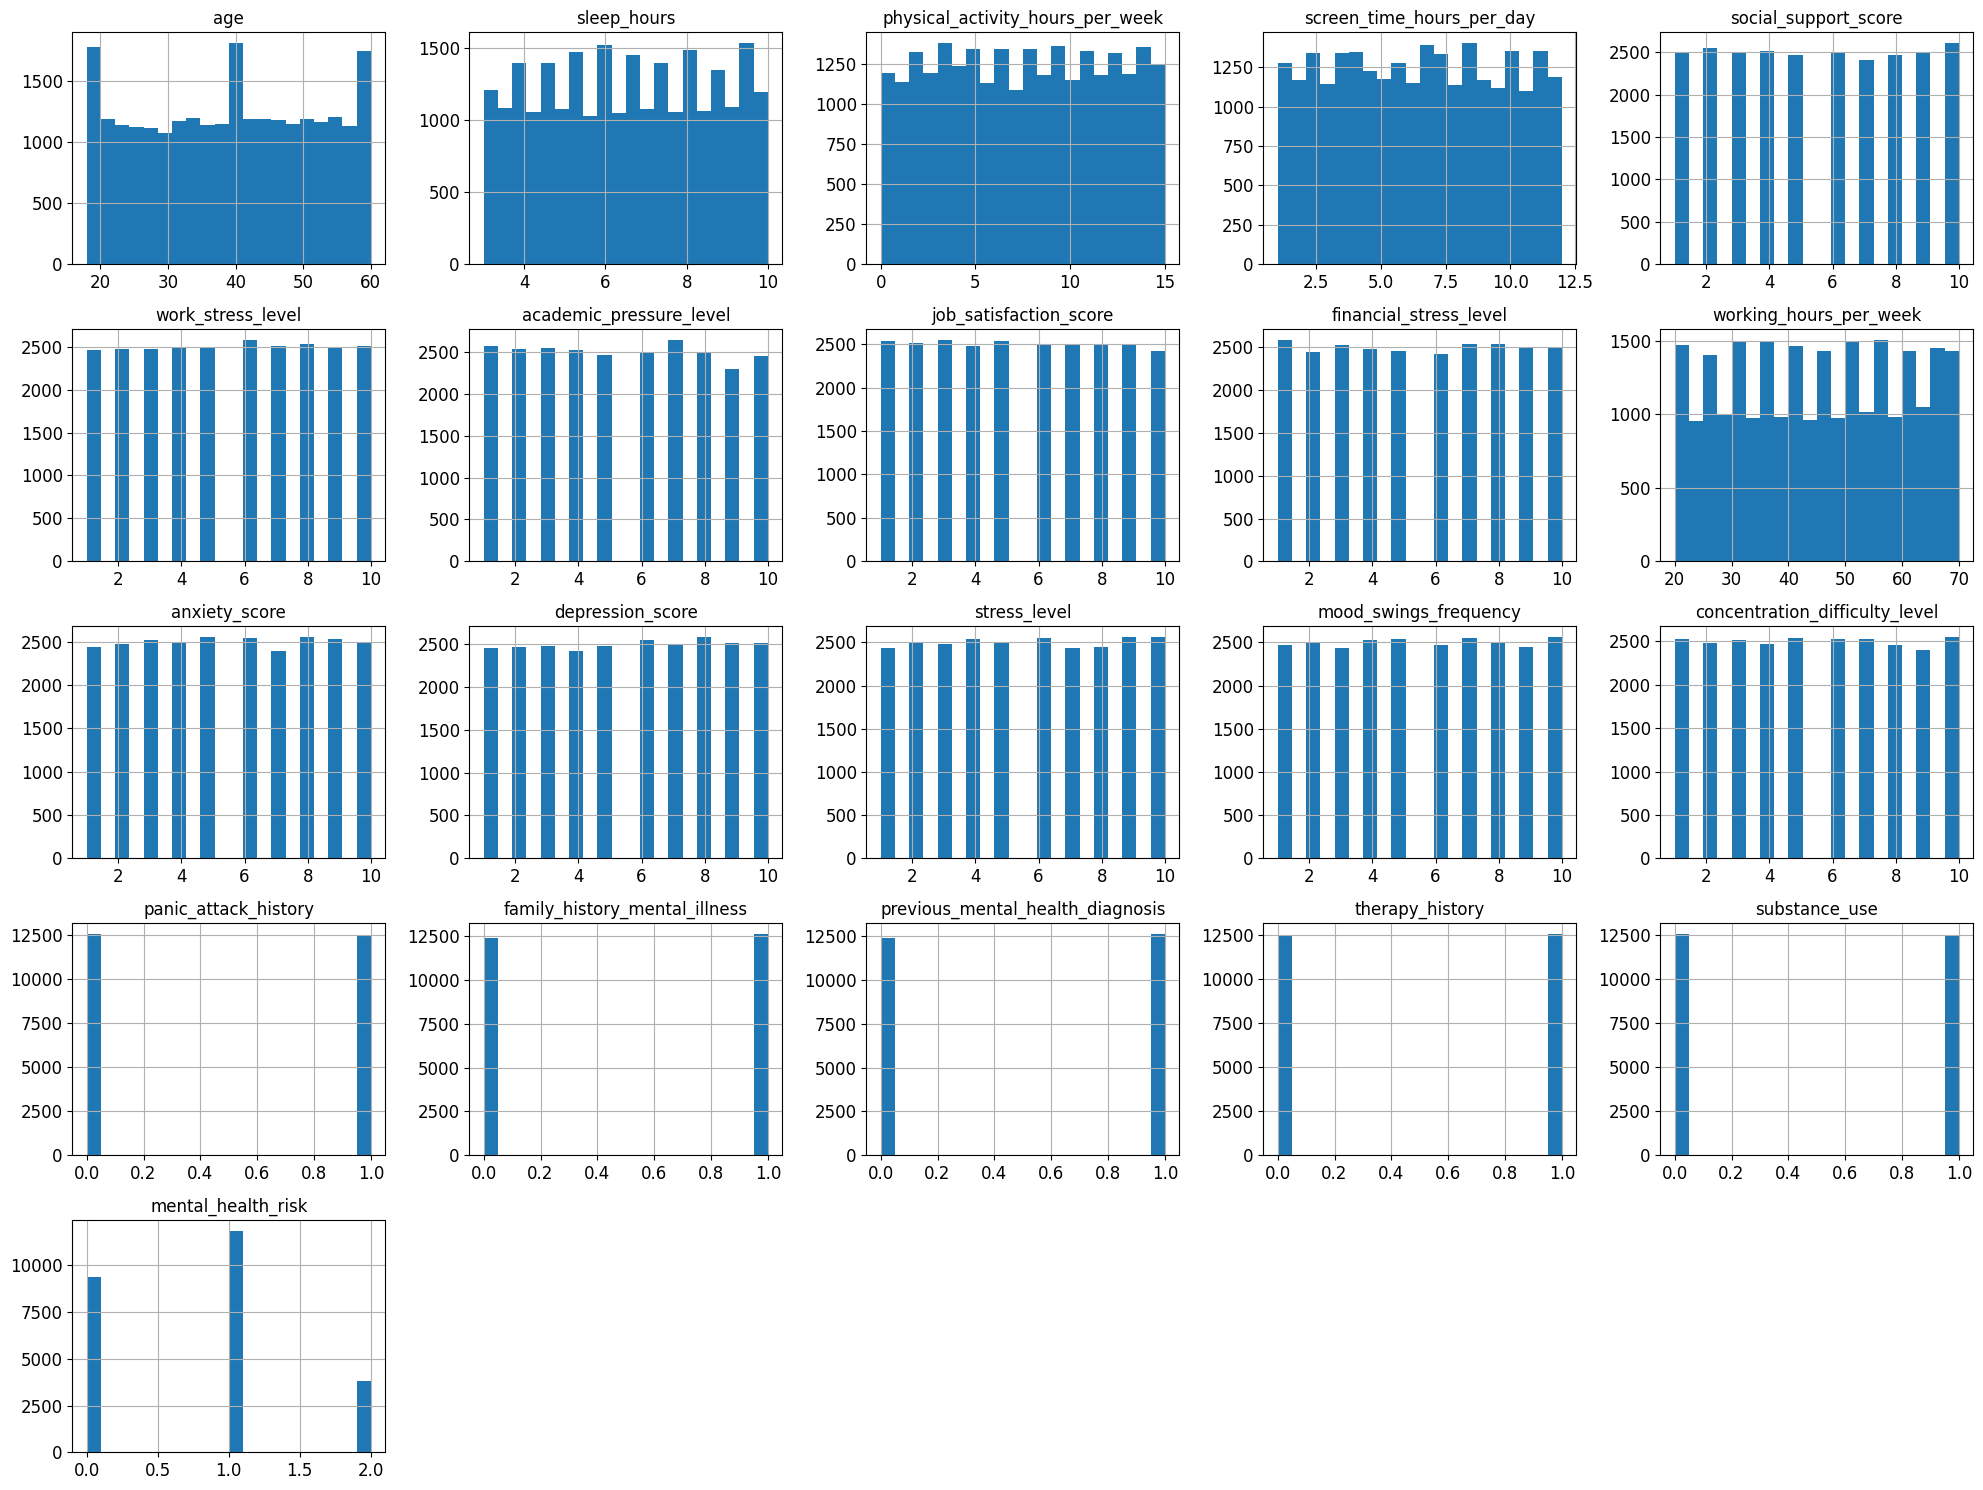

In [23]:
import matplotlib.pyplot as plt

dataset.hist(bins=20, figsize=(20, 15))
plt.tight_layout()
plt.show()

---
## Pré-processamento
---

Apliquei One-Hot Encoding para transformar variáveis de texto em variáveis numéricas usando get_dummies() da biblioteca pandas.

In [24]:
print(f"Antes da transformação: {dataset.shape}")

Antes da transformação: (25000, 25)


In [25]:
dataset.head()

,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,...,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.6,2.8,9.6,7,10,...,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.5,2.7,3.0,10,6,...,7,4,9,3,0,0,0,0,0,0
2,56,Female,Divorced,Bachelor,Student,3.1,14.1,7.2,10,5,...,3,1,4,2,1,1,1,1,1,2
3,59,Other,Married,Bachelor,Employed,7.0,0.5,10.3,2,10,...,8,5,2,5,1,1,0,1,1,2
4,58,Male,Single,High School,Self-Employed,5.1,2.5,1.2,8,1,...,8,3,3,1,0,0,1,0,1,0


In [26]:
df_processado = pd.get_dummies(dataset)
print(f"Após a transformação: {df_processado.shape}")

Após a transformação: (25000, 35)


In [27]:
df_processado.head()

,age,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,working_hours_per_week,...,marital_status_Married,marital_status_Single,education_level_Bachelor,education_level_High School,education_level_Master,education_level_PhD,employment_status_Employed,employment_status_Self-Employed,employment_status_Student,employment_status_Unemployed
0,56,8.6,2.8,9.6,7,10,3,7,8,40,...,False,True,True,False,False,False,False,False,False,True
1,47,4.5,2.7,3.0,10,6,9,1,10,31,...,False,True,True,False,False,False,False,False,False,True
2,56,3.1,14.1,7.2,10,5,2,4,7,28,...,False,False,True,False,False,False,False,False,True,False
3,59,7.0,0.5,10.3,2,10,4,8,7,63,...,True,False,True,False,False,False,True,False,False,False
4,58,5.1,2.5,1.2,8,1,8,8,3,28,...,False,True,False,True,False,False,False,True,False,False


Calculei a correlação matemática entre as variáveis para mostrar como isso se relaciona com o risco de saúde mental.

In [28]:
import seaborn as sns
corr_matrix = df_processado.corr()
print(corr_matrix["mental_health_risk"].sort_values(ascending=False))

mental_health_risk                  1.000000
panic_attack_history                0.422517
anxiety_score                       0.323683
depression_score                    0.321500
family_history_mental_illness       0.208768
work_stress_level                   0.152105
financial_stress_level              0.149601
marital_status_Single               0.023627
education_level_PhD                 0.010124
substance_use                       0.006668
gender_Female                       0.005072
academic_pressure_level             0.004481
employment_status_Unemployed        0.003200
concentration_difficulty_level      0.002001
screen_time_hours_per_day           0.001415
education_level_Master              0.000947
employment_status_Self-Employed     0.000821
therapy_history                     0.000761
job_satisfaction_score              0.000548
gender_Other                        0.000476
stress_level                       -0.000284
employment_status_Student          -0.000514
working_ho

---
## Preparação dos Dados para os Algoritmos de Machine Learning
---

Separei as variaveis das possiveis causas (X) e a variavel de efeito (Y)

In [30]:
X = df_processado.drop('mental_health_risk', axis=1)
y = df_processado['mental_health_risk']

Dividi o conjunto de dados em 80% para treino e 20% para teste.

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensões do Treinamento (X_train): {X_train.shape}")
print(f"Dimensões do Teste (X_test): {X_test.shape}")

Dimensões do Treinamento (X_train): (20000, 34)
Dimensões do Teste (X_test): (5000, 34)


---
## Treinamento do Modelos
---

Meu objetivo é prever as categorias de risco.Para isso vou usar os algoritimos LogisticRegression, DecisionTreeClassifier e RandomForestClassifier.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np

modelo_linear = LogisticRegression(max_iter=2000, random_state=42)
modelo_arvore = DecisionTreeClassifier(random_state=42)
modelo_floresta = RandomForestClassifier(random_state=42)

print("Modelos prontos para treinamento.")

Modelos prontos para treinamento.


### Overfitting

O material de referencia mostra que treinar e testar o modelo só uma vez com o X_train gera um resultado não confiavel.

In [38]:
from sklearn.metrics import accuracy_score

modelo_linear.fit(X_train, y_train)
modelo_arvore.fit(X_train, y_train)
modelo_floresta.fit(X_train, y_train)

prev_treino_linear = modelo_linear.predict(X_train)
prev_treino_arvore = modelo_arvore.predict(X_train)
prev_treino_floresta = modelo_floresta.predict(X_train)

print("--- Acurácia no próprio conjunto de Treinamento ---")
print(f"Regressão Logística: {accuracy_score(y_train, prev_treino_linear) * 100:.2f}%")
print(f"Árvore de Decisão: {accuracy_score(y_train, prev_treino_arvore) * 100:.2f}%")
print(f"Random Forest: {accuracy_score(y_train, prev_treino_floresta) * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Acurácia no próprio conjunto de Treinamento ---
Regressão Logística: 74.68%
Árvore de Decisão: 100.00%
Random Forest: 100.00%


Observando o resultado, a Árvore de Decisão e o Random Forest atingiu 100% de acurácia. Isso é um sinal de Overfitting, ou seja, o modelo não aprendeu mas sim decorou os resultados.

### Validação Cruzada

Para testar e descobrir o melhor modelo com precisão, divide o X-train em 5 partes, treinando e avaliando o modelos varias vezes. Para medir a acuraria do treinamento, calculei a media de acerto e o desvio padrão.

In [39]:
from sklearn.model_selection import cross_val_score

def display_scores(scores, nome_modelo):
    print(f"--- {nome_modelo} ---")
    print(f"Acurácias das 5 partes: {scores}")
    print(f"Média de Acerto: {scores.mean():.4f} ({(scores.mean()*100):.2f}%)")
    print(f"Desvio Padrão: {scores.std():.4f}\n")

# Regressão Logística
scores_linear = cross_val_score(modelo_linear, X_train, y_train, scoring="accuracy", cv=5)
display_scores(scores_linear, "Regressão Logística")

# Árvore de Decisão
scores_arvore = cross_val_score(modelo_arvore, X_train, y_train, scoring="accuracy", cv=5)
display_scores(scores_arvore, "Árvore de Decisão")

# Random Forest
scores_floresta = cross_val_score(modelo_floresta, X_train, y_train, scoring="accuracy", cv=5)
display_scores(scores_floresta, "Random Forest")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

--- Regressão Logística ---
Acurácias das 5 partes: [0.74625 0.74825 0.748   0.75225 0.73475]
Média de Acerto: 0.7459 (74.59%)
Desvio Padrão: 0.0059

--- Árvore de Decisão ---
Acurácias das 5 partes: [0.9915  0.991   0.99025 0.99175 0.989  ]
Média de Acerto: 0.9907 (99.07%)
Desvio Padrão: 0.0010

--- Random Forest ---
Acurácias das 5 partes: [0.9565 0.952  0.951  0.963  0.96  ]
Média de Acerto: 0.9565 (95.65%)
Desvio Padrão: 0.0046



A Validação Cruzada mostrou que o algoritimo com a melhor performance média foi o algoritmo de Árvore de Decisão, com uma média de acertos de 99.07%.

---
## Aplicando o Conjunto de Teste
---

Mesmo sabendo quem é o vencedor, para a avaliação final, vou testar e comparar os tres modelos. Dessa forma, será possivel enxergar melhor a diferença entre cada um deles em um gráfico.

In [41]:
from sklearn.metrics import accuracy_score

print("Realizando treinamento...")
modelo_linear.fit(X_train, y_train)
modelo_arvore.fit(X_train, y_train)
modelo_floresta.fit(X_train, y_train)

prev_final_linear = modelo_linear.predict(X_test)
prev_final_arvore = modelo_arvore.predict(X_test)
prev_final_floresta = modelo_floresta.predict(X_test)

acuracia_linear = accuracy_score(y_test, prev_final_linear)
acuracia_arvore = accuracy_score(y_test, prev_final_arvore)
acuracia_floresta = accuracy_score(y_test, prev_final_floresta)

print(f"--- Conjunto de Teste ---")
print(f"Regressão Logística: {acuracia_linear * 100:.2f}%")
print(f"Árvore de Decisão: {acuracia_arvore * 100:.2f}%")
print(f"Random Forest: {acuracia_floresta * 100:.2f}%\n")

Realizando treinamento...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Conjunto de Teste ---
Regressão Logística: 74.40%
Árvore de Decisão: 99.24%
Random Forest: 96.12%



### Gráfico de Comparação dos Modelos

In [53]:
import matplotlib.pyplot as plt
import numpy as np

categorias = ['Risco Baixo (0)', 'Risco Moderado (1)', 'Risco Alto (2)']
x = np.arange(len(categorias))
largura = 0.35

# Quantidade real (y_test)
real_counts = y_test.value_counts().sort_index().values

# Quantidade predita por cada modelo
prev_linear_counts = np.bincount(prev_final_linear, minlength=3)
prev_arvore_counts = np.bincount(prev_final_arvore, minlength=3)
prev_floresta_counts = np.bincount(prev_final_floresta, minlength=3)

Regressão Logística (Real vs Predito)

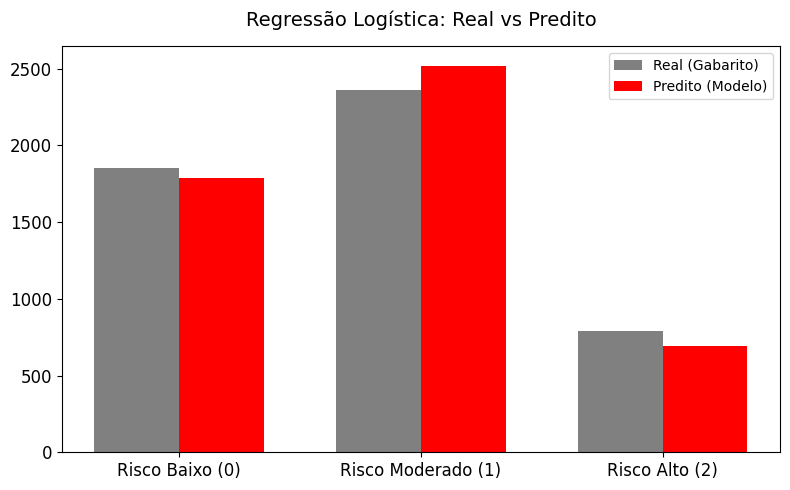

In [57]:
plt.figure(figsize=(8, 5))
plt.bar(x - largura/2, real_counts, largura, label='Real (Gabarito)', color='gray')
plt.bar(x + largura/2, prev_linear_counts, largura, label='Predito (Modelo)', color='red')
plt.title('Regressão Logística: Real vs Predito', fontsize=14, pad=15)
plt.xticks(x, categorias)
plt.legend()
plt.tight_layout()
plt.show()

Árvore de Decisão (Real vs Predito)

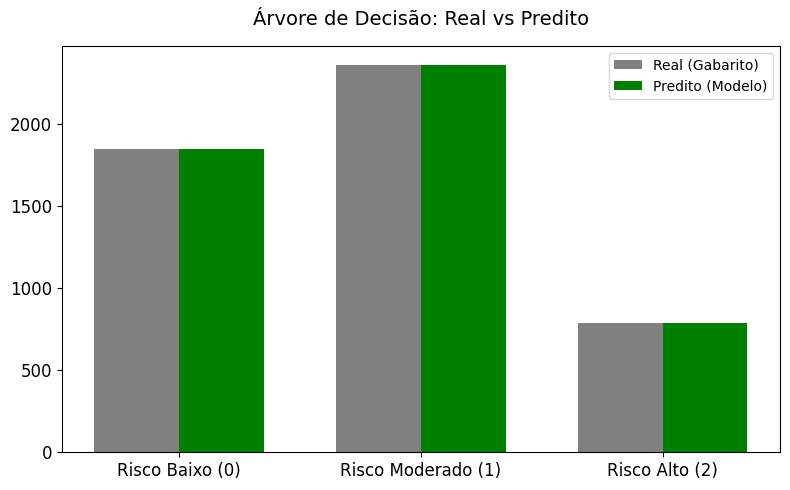

In [56]:
plt.figure(figsize=(8, 5))
plt.bar(x - largura/2, real_counts, largura, label='Real (Gabarito)', color='gray')
plt.bar(x + largura/2, prev_arvore_counts, largura, label='Predito (Modelo)', color='green')
plt.title('Árvore de Decisão: Real vs Predito', fontsize=14, pad=15)
plt.xticks(x, categorias)
plt.legend()
plt.tight_layout()
plt.show()

Random Forest (Real vs Predito)

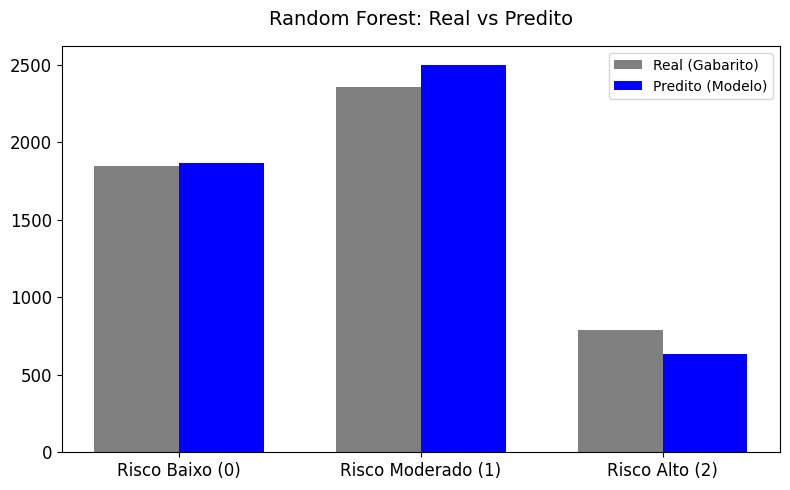

In [55]:
plt.figure(figsize=(8, 5))
plt.bar(x - largura/2, real_counts, largura, label='Real (Gabarito)', color='gray')
plt.bar(x + largura/2, prev_floresta_counts, largura, label='Predito (Modelo)', color='blue')
plt.title('Random Forest: Real vs Predito', fontsize=14, pad=15)
plt.xticks(x, categorias)
plt.legend()
plt.tight_layout()
plt.show()

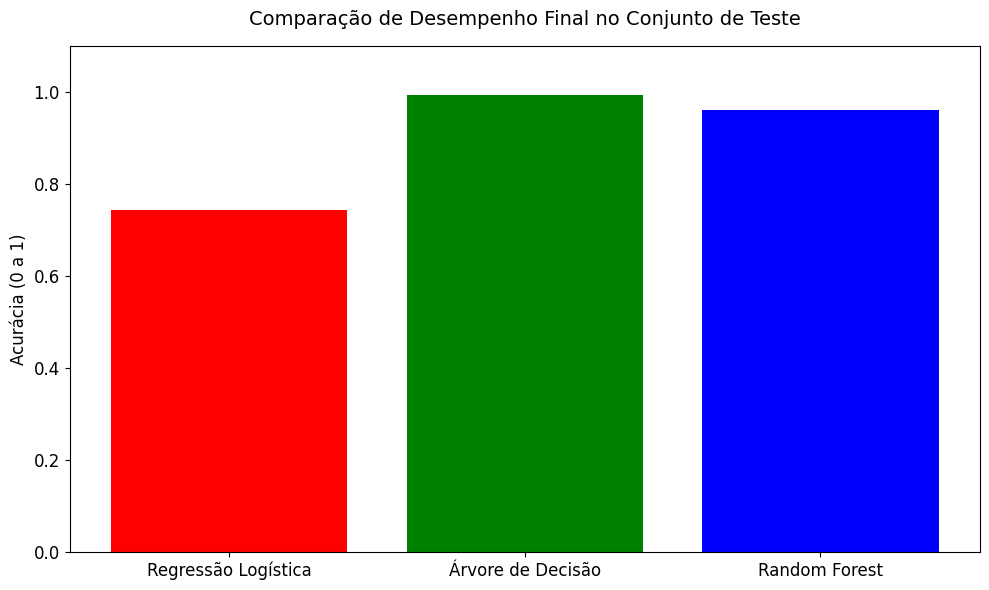

In [45]:
import matplotlib.pyplot as plt

modelos = ['Regressão Logística', 'Árvore de Decisão', 'Random Forest']
acuracias = [acuracia_linear, acuracia_arvore, acuracia_floresta]

plt.figure(figsize=(10, 6))
bars = plt.bar(modelos, acuracias, color=['red', 'green', 'blue'])
plt.title('Comparação de Desempenho Final no Conjunto de Teste', fontsize=14, pad=15)
plt.ylabel('Acurácia (0 a 1)', fontsize=12)
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()